In [1]:
!unzip fine_tuning.zip

Archive:  fine_tuning.zip
   creating: fine_tuning/
  inflating: fine_tuning/bert_fine_tuning_peft.py  
   creating: fine_tuning/best_params/
   creating: fine_tuning/best_params/.ipynb_checkpoints/
  inflating: fine_tuning/best_params/.ipynb_checkpoints/get_best_params-checkpoint.ipynb  
  inflating: fine_tuning/best_params/best_params.xlsx  
   creating: fine_tuning/best_params/checkpoint-1000/
  inflating: fine_tuning/best_params/checkpoint-1000/adapter_config.json  
  inflating: fine_tuning/best_params/checkpoint-1000/adapter_model.safetensors  
  inflating: fine_tuning/best_params/checkpoint-1000/optimizer.pt  
  inflating: fine_tuning/best_params/checkpoint-1000/README.md  
  inflating: fine_tuning/best_params/checkpoint-1000/rng_state.pth  
  inflating: fine_tuning/best_params/checkpoint-1000/scheduler.pt  
  inflating: fine_tuning/best_params/checkpoint-1000/sentencepiece.bpe.model  
  inflating: fine_tuning/best_params/checkpoint-1000/special_tokens_map.json  
  inflating: fin

In [2]:
%cd fine_tuning

/content/fine_tuning


In [3]:
!pip install -r requirements.txt

  Cloning https://github.com/huggingface/peft (to revision cf04d0353f0343cbf66627228c4495f51669af34) to /tmp/pip-install-xpmjtriy/peft_9e214ec67f3b4fd081c48b9a4de8e484
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/peft /tmp/pip-install-xpmjtriy/peft_9e214ec67f3b4fd081c48b9a4de8e484
  Running command git rev-parse -q --verify 'sha^cf04d0353f0343cbf66627228c4495f51669af34'
  Running command git fetch -q https://github.com/huggingface/peft cf04d0353f0343cbf66627228c4495f51669af34
  Running command git checkout -q cf04d0353f0343cbf66627228c4495f51669af34
  Resolved https://github.com/huggingface/peft to commit cf04d0353f0343cbf66627228c4495f51669af34
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5

In [4]:
import pandas as pd
import numpy as np
import os
import torch
import time
import json

from peft import LoraConfig, LoraModel, get_peft_model, TaskType
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"
use_cuda = torch.cuda.is_available()

In [13]:
df = pd.read_csv('dataset/all_data.csv')
train_data = pd.read_csv('dataset/train_augmented.csv')
train_data['label'] = train_data['label'].str.capitalize()
val_data = pd.read_csv('dataset/val.csv')
test_data = pd.read_csv('dataset/test.csv')

# Length train, val, and test
print("Train: ",len(train_data))
print("Val: ",len(val_data))
print("Test: ",len(test_data))

Train:  8472
Val:  1062
Test:  1062


In [14]:
tags = np.unique(df['label'])
num_labels = len(tags)
max_length = 128
label2id = {t: i for i, t in enumerate(tags)}
id2label = {i: t for i, t in enumerate(tags)}

In [15]:
def model_init(model_name):
    global tokenizer
    global data_collator
    global tr_model

    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name, model_max_length=128)

    # Configure LoRA
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8, # Rank of the low-rank matrices
        lora_alpha=32,
        lora_dropout=0.1
    )

    # Wrap the base model with the LoRA configuration
    model = get_peft_model(base_model, lora_config)
    model.print_trainable_parameters()

    return model, tokenizer


def tokenize_function(examples):
    # process the input sequence
    tokenized_input = tokenizer(examples["tweet"],
                                truncation=True,
                                padding='max_length',
                                max_length=max_length)
    # process the labels
    tokenized_input['label'] = [label2id[lb] for lb in examples['label']]

    return tokenized_input


def preprocessing():
    X_train = Dataset.from_pandas(train_data)
    X_val = Dataset.from_pandas(val_data)
    X_test = Dataset.from_pandas(test_data)

    tokenized_train_data = X_train.map(tokenize_function, batched=True)
    tokenized_val_data = X_val.map(tokenize_function, batched=True)
    tokenized_test_data = X_test.map(tokenize_function, batched=True)

    return tokenized_train_data, tokenized_val_data, tokenized_test_data


def compute_metrics(p):
    pred, labels = p
    pred = np.argmax(pred, axis=1)

    true_labels = [tags[l] for l in labels]
    true_predictions = [tags[pr] for pr in pred]

    report = classification_report(true_labels, true_predictions, digits=4)
    acc = accuracy_score(y_true=true_labels, y_pred=true_predictions)
    rec = recall_score(y_true=true_labels, y_pred=true_predictions, average="macro")
    prec = precision_score(y_true=true_labels, y_pred=true_predictions, average="macro")
    f1 = f1_score(y_true=true_labels, y_pred=true_predictions, average="macro", zero_division=1.0)

    print("Classification Report:\n{}".format(report))
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [16]:
# to generate the confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def generate_confusion_matrix(true_labels, pred_labels, num_labels):
    cm = confusion_matrix(true_labels, pred_labels)
    labels = [id2label[i] for i in range(num_labels)]
    plt.figure(figsize=(8, 6))
    sns.set(font_scale=1.5)
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=labels,
                yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.yticks(rotation=0)
    plt.show()

In [17]:
def train_model(model_name, output_dir, learning_rate, train_batch_size, eval_batch_size, num_epochs, weight_decay):

    model, tokenizer = model_init(model_name)
    train_tokenized, val_tokenized, test_tokenized = preprocessing()

    training_args = TrainingArguments(
        output_dir=output_dir,
        logging_strategy="epoch",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit = 1,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        #push_to_hub=True, # to push to hub during the training
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    trainer.save_model(output_dir)
    #trainer.push_to_hub(commit_message="Training complete")

    # Get the evaluation results
    trainer.eval_dataset=test_tokenized
    evaluation_results = trainer.evaluate()
    print(evaluation_results)

    # make prediction on the test set
    predictions = trainer.predict(test_tokenized)
    pred_labels = np.argmax(predictions.predictions, axis=1)
    true_labels = test_tokenized["label"]

    # Generate confusion matrix
    generate_confusion_matrix(true_labels, pred_labels, num_labels)

    return trainer

In [18]:

def show_log_history(trainer):
    log_history = pd.DataFrame(trainer.state.log_history)
    log_history = log_history.fillna(0)
    log_history = log_history.groupby(["epoch"]).sum()

    log_history[["loss", "eval_loss"]].plot()
    plt.show()

In [19]:
def main(model_name, output_dir, best_params):
    start = time.time()
     # load json file containing best params
    best_params = best_params

    with open(best_params, 'r') as js:
        data = json.load(js)

    print(data)

    # define best params
    num_train_epochs = data['num_train_epochs']
    learning_rate = data['learning_rate']
    train_batch_size = data['per_device_train_batch_size']
    eval_batch_size = data['per_device_eval_batch_size']
    weight_decay = data['weight_decay']

    # training
    tr_model = train_model(model_name=model_name,
                           output_dir=output_dir,
                           learning_rate=learning_rate,
                           train_batch_size=train_batch_size,
                           eval_batch_size=eval_batch_size,
                           num_epochs=num_train_epochs,
                           weight_decay=weight_decay)

    print('Training finished!')

    show_log_history(tr_model)


    end = time.time()
    exec_time = (end - start) / 60
    print(f'Total time: {exec_time} minutes')

{'num_train_epochs': 10, 'learning_rate': 0.0003, 'per_device_train_batch_size': 8, 'per_device_eval_batch_size': 32, 'weight_decay': 0.0002815242487947289}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobertweet-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 299,526 || all params: 110,862,348 || trainable%: 0.27017829353569167


Map:   0%|          | 0/8472 [00:00<?, ? examples/s]

Map:   0%|          | 0/1062 [00:00<?, ? examples/s]

...

wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 21523190 (21523190-universitas-islam-indonesia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.897000,0.788982,0.714689,0.720955,0.755421,0.726945
2,0.638700,0.757157,0.740113,0.743186,0.770024,0.749287
3,0.545400,0.766366,0.760829,0.767866,0.773650,0.768829
4,0.465500,0.806380,0.763653,0.763522,0.778072,0.769284
5,0.413600,0.880607,0.764595,0.767897,0.780410,0.772177
6,0.366700,1.035112,0.751412,0.751090,0.781081,0.760334
7,0.335600,0.984224,0.776836,0.778041,0.791022,0.783089
8,0.286700,1.074149,0.757062,0.756762,0.773628,0.763580
9,0.260500,1.124262,0.758004,0.758247,0.775638,0.764922
10,0.237100,1.152113,0.755179,0.754929,0.774222,0.762284


Classification Report:
              precision    recall  f1-score   support

       Anger     0.7014    0.8807    0.7809       176
        Fear     0.8500    0.8095    0.8293       147
         Joy     0.6402    0.7740    0.7008       177
        Love     0.6736    0.8435    0.7490       115
     Neutral     0.7697    0.4597    0.5756       298
         Sad     0.6909    0.7651    0.7261       149

    accuracy                         0.7147      1062
   macro avg     0.7210    0.7554    0.7269      1062
weighted avg     0.7264    0.7147    0.7055      1062

Classification Report:
              precision    recall  f1-score   support

       Anger     0.7346    0.8807    0.8010       176
        Fear     0.8414    0.8299    0.8356       147
         Joy     0.7590    0.7119    0.7347       177
        Love     0.6168    0.8957    0.7305       115
     Neutral     0.7414    0.5772    0.6491       298
         Sad     0.7660    0.7248    0.7448       149

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       Anger     0.7431    0.9000    0.8141       180
        Fear     0.8227    0.8657    0.8436       134
         Joy     0.8058    0.7981    0.8019       208
        Love     0.6051    0.9406    0.7364       101
     Neutral     0.8143    0.5876    0.6826       291
         Sad     0.7846    0.6892    0.7338       148

    accuracy                         0.7646      1062
   macro avg     0.7626    0.7969    0.7688      1062
weighted avg     0.7776    0.7646    0.7608      1062

{'eval_loss': 0.703770637512207, 'eval_accuracy': 0.7645951035781544, 'eval_precision': 0.762606030756143, 'eval_recall': 0.7968601132404132, 'eval_f1': 0.7687534785418763, 'eval_runtime': 2.0271, 'eval_samples_per_second': 523.899, 'eval_steps_per_second': 16.773, 'epoch': 10.0}
Classification Report:
              precision    recall  f1-score   support

       Anger     0.7431    0.9000    0.8141       180
        Fear     0.82

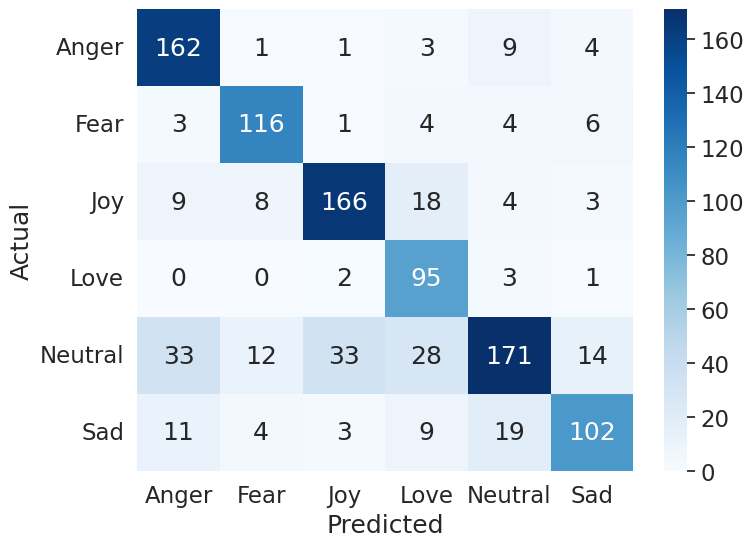

Training finished!


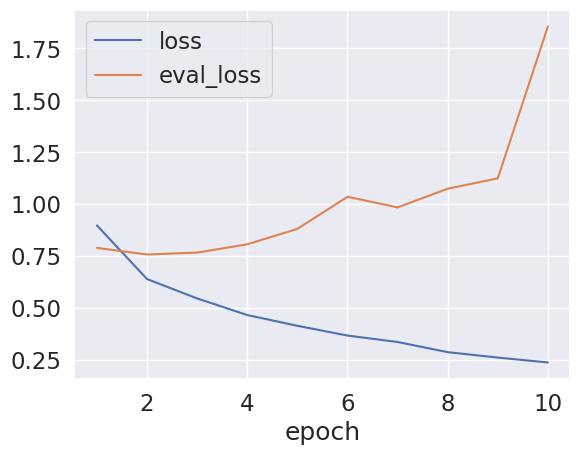

Total time: 8.620015347003937 minutes


In [20]:
#1 IndoBERTweet peft

main(
    model_name = 'indolem/indobertweet-base-uncased',
    output_dir = 'p-emotcls-indobertweet-base',
    best_params = 'best_params/p-indobertweet.json'
)

{'num_train_epochs': 7, 'learning_rate': 0.0003, 'per_device_train_batch_size': 16, 'per_device_eval_batch_size': 8, 'weight_decay': 0.0981507466116051}


config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

Classification Report:
              precision    recall  f1-score   support

       Anger     0.1695    1.0000    0.2899       180
        Fear     0.0000    0.0000    0.0000       134
         Joy     0.0000    0.0000    0.0000       208
        Love     0.0000    0.0000    0.0000       101
     Neutral     0.0000    0.0000    0.0000       291
         Sad     0.0000    0.0000    0.0000       148

    accuracy                         0.1695      1062
   macro avg     0.0282    0.1667    0.0483      1062
weighted avg     0.0287    0.1695    0.0491      1062

{'eval_loss': 1.7732396125793457, 'eval_accuracy': 0.1694915254237288, 'eval_precision': 0.02824858757062147, 'eval_recall': 0.16666666666666666, 'eval_f1': 0.04830917874396135, 'eval_runtime': 6.7318, 'eval_samples_per_second': 157.758, 'eval_steps_per_second': 19.757, 'epoch': 7.0}


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

Classification Report:
              precision    recall  f1-score   support

       Anger     0.1695    1.0000    0.2899       180
        Fear     0.0000    0.0000    0.0000       134
         Joy     0.0000    0.0000    0.0000       208
        Love     0.0000    0.0000    0.0000       101
     Neutral     0.0000    0.0000    0.0000       291
         Sad     0.0000    0.0000    0.0000       148

    accuracy                         0.1695      1062
   macro avg     0.0282    0.1667    0.0483      1062
weighted avg     0.0287    0.1695    0.0491      1062



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

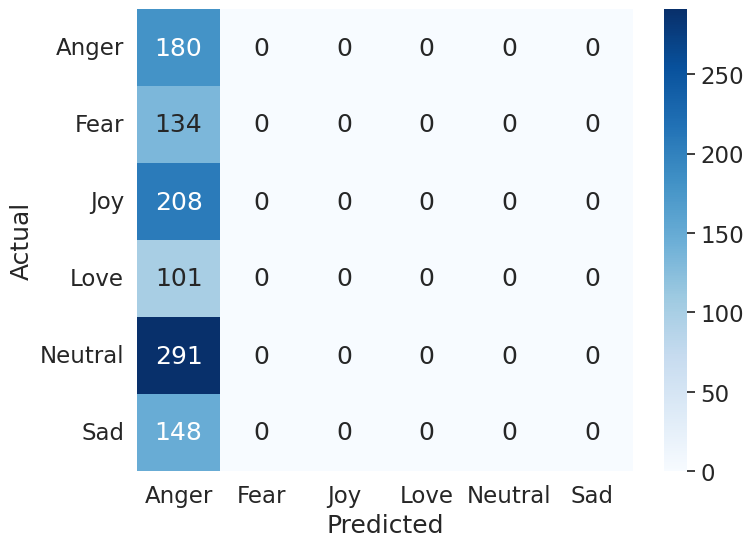

Training finished!


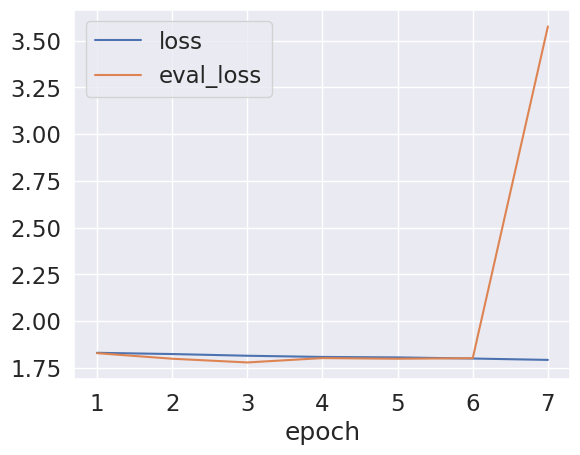

Total time: 13.144048023223878 minutes


In [21]:
#2 FacebookAI/xlm-roberta-large peft

main(
    model_name = 'FacebookAI/xlm-roberta-large',
    output_dir = 'p-emotcls-xlm-r-large',
    best_params = 'best_params/p-xlm-r-large.json'
)

{'num_train_epochs': 6, 'learning_rate': 0.0003, 'per_device_train_batch_size': 32, 'per_device_eval_batch_size': 16, 'weight_decay': 0.07929004945062951}


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/1062 [00:00<?, ? examples/s]

Map:   0%|          | 0/1062 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.241600,0.887337,0.700565,0.704042,0.744107,0.709622
2,0.862700,0.813997,0.721281,0.724931,0.757251,0.729714
3,0.751600,0.761237,0.733522,0.743677,0.754532,0.742768
4,0.674700,0.757132,0.734463,0.740886,0.763343,0.744321
5,0.630300,0.748240,0.748588,0.746312,0.778124,0.756814
6,0.596200,0.746538,0.745763,0.743960,0.775546,0.754224


Classification Report:
              precision    recall  f1-score   support

       Anger     0.7031    0.7670    0.7337       176
        Fear     0.7707    0.8231    0.7961       147
         Joy     0.7222    0.7345    0.7283       177
        Love     0.6273    0.8783    0.7319       115
     Neutral     0.8118    0.4631    0.5897       298
         Sad     0.5891    0.7987    0.6781       149

    accuracy                         0.7006      1062
   macro avg     0.7040    0.7441    0.7096      1062
weighted avg     0.7219    0.7006    0.6930      1062

Classification Report:
              precision    recall  f1-score   support

       Anger     0.6890    0.8182    0.7481       176
        Fear     0.8264    0.8095    0.8179       147
         Joy     0.7771    0.7288    0.7522       177
        Love     0.6352    0.8783    0.7372       115
     Neutral     0.8125    0.5235    0.6367       298
         Sad     0.6094    0.7852    0.6862       149

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       Anger     0.7760    0.7889    0.7824       180
        Fear     0.7358    0.8731    0.7986       134
         Joy     0.8250    0.7933    0.8088       208
        Love     0.7328    0.8416    0.7834       101
     Neutral     0.7877    0.5739    0.6640       291
         Sad     0.6042    0.7838    0.6824       148

    accuracy                         0.7458      1062
   macro avg     0.7436    0.7758    0.7533      1062
weighted avg     0.7557    0.7458    0.7433      1062

{'eval_loss': 0.7114838361740112, 'eval_accuracy': 0.7457627118644068, 'eval_precision': 0.7435777461949509, 'eval_recall': 0.7757572586213302, 'eval_f1': 0.7532677452836412, 'eval_runtime': 2.1144, 'eval_samples_per_second': 502.275, 'eval_steps_per_second': 31.688, 'epoch': 6.0}
Classification Report:
              precision    recall  f1-score   support

       Anger     0.7760    0.7889    0.7824       180
        Fear     0.7

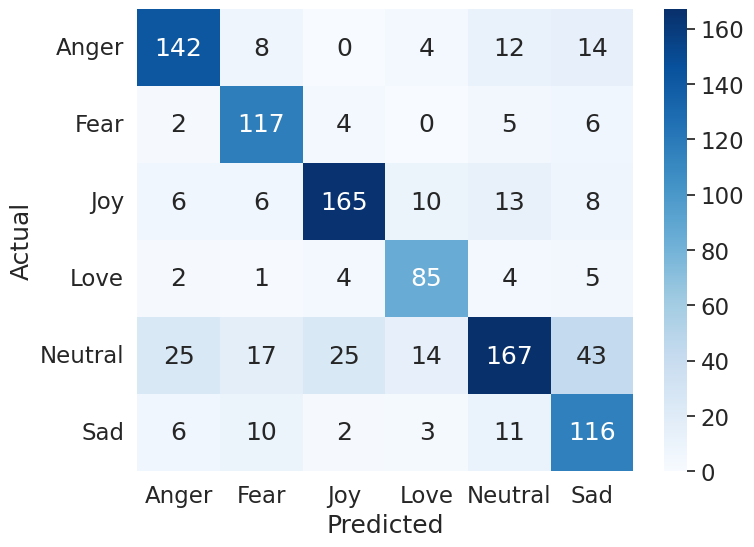

Training finished!


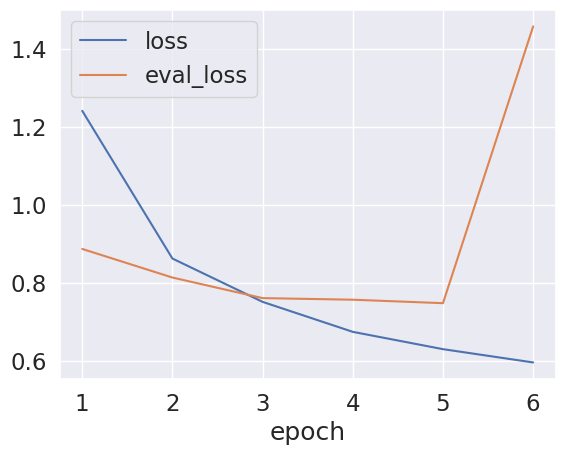

Total time: 3.6684837261835734 minutes


In [22]:
#3 FacebookAI/xlm-roberta-base peft

main(
    model_name = 'FacebookAI/xlm-roberta-base',
    output_dir = 'p-emotcls-xlm-r-base',
    best_params = 'best_params/p-xlm-r-base.json'
)

{'num_train_epochs': 10, 'learning_rate': 0.0003, 'per_device_train_batch_size': 32, 'per_device_eval_batch_size': 8, 'weight_decay': 0.08342241849615926}


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/1062 [00:00<?, ? examples/s]

Map:   0%|          | 0/1062 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.569500,1.364086,0.480226,0.482267,0.506862,0.481740
2,1.113100,1.166060,0.579096,0.604500,0.621873,0.587733
3,0.946000,0.997995,0.646893,0.655320,0.665380,0.655664
4,0.838600,1.002697,0.652542,0.662426,0.673635,0.659931
5,0.761600,0.947121,0.693032,0.692108,0.720066,0.700253
6,0.694100,0.946323,0.677966,0.685416,0.705250,0.686218
7,0.649800,0.927921,0.698682,0.697118,0.725313,0.706892
8,0.615700,0.930114,0.694915,0.694667,0.725180,0.704043
9,0.588400,0.908768,0.701507,0.703588,0.721525,0.709862
10,0.564400,0.911775,0.698682,0.701027,0.718135,0.707140


Classification Report:
              precision    recall  f1-score   support

       Anger     0.3611    0.2955    0.3250       176
        Fear     0.5570    0.5986    0.5770       147
         Joy     0.6641    0.4802    0.5574       177
        Love     0.4951    0.8783    0.6332       115
     Neutral     0.5216    0.4463    0.4810       298
         Sad     0.2948    0.3423    0.3168       149

    accuracy                         0.4802      1062
   macro avg     0.4823    0.5069    0.4817      1062
weighted avg     0.4889    0.4802    0.4746      1062

Classification Report:
              precision    recall  f1-score   support

       Anger     0.4631    0.5341    0.4960       176
        Fear     0.7404    0.5238    0.6135       147
         Joy     0.7170    0.6441    0.6786       177
        Love     0.5153    0.8783    0.6495       115
     Neutral     0.7143    0.3859    0.5011       298
         Sad     0.4770    0.7651    0.5876       149

    accuracy                   

Classification Report:
              precision    recall  f1-score   support

       Anger     0.7267    0.6944    0.7102       180
        Fear     0.7383    0.8209    0.7774       134
         Joy     0.8261    0.7308    0.7755       208
        Love     0.6797    0.8614    0.7598       101
     Neutral     0.6561    0.5704    0.6103       291
         Sad     0.6193    0.7365    0.6728       148

    accuracy                         0.7053      1062
   macro avg     0.7077    0.7357    0.7177      1062
weighted avg     0.7089    0.7053    0.7036      1062

{'eval_loss': 0.9255515336990356, 'eval_accuracy': 0.7052730696798494, 'eval_precision': 0.7077030566928197, 'eval_recall': 0.7357380930162121, 'eval_f1': 0.7176802645250535, 'eval_runtime': 2.5002, 'eval_samples_per_second': 424.772, 'eval_steps_per_second': 53.197, 'epoch': 10.0}
Classification Report:
              precision    recall  f1-score   support

       Anger     0.7267    0.6944    0.7102       180
        Fear     0.

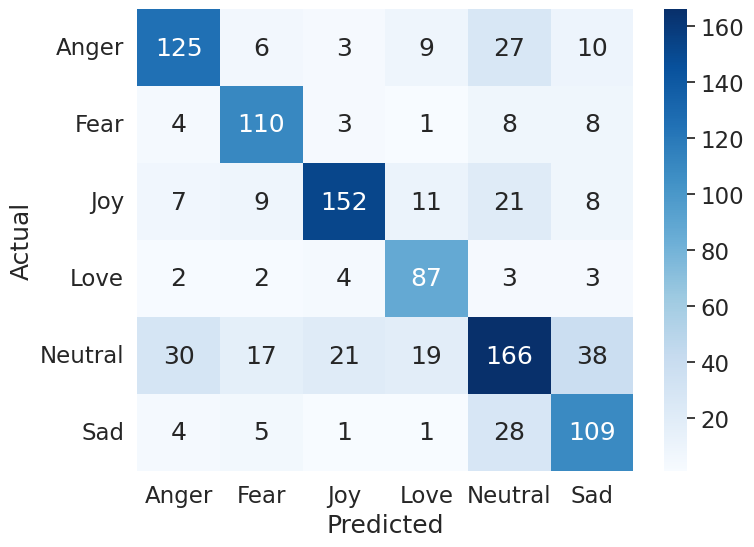

Training finished!


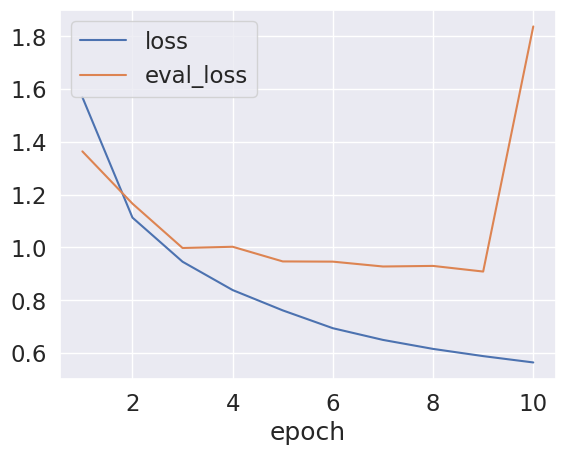

Total time: 6.093537779649099 minutes


In [23]:
#4 google-bert/bert-base-multilingual-cased peft

main(
    model_name = 'google-bert/bert-base-multilingual-cased',
    output_dir = 'p-emotcls-bert-base',
    best_params = 'best_params/p-mbert.json'
)

{'num_train_epochs': 7, 'learning_rate': 0.0003, 'per_device_train_batch_size': 16, 'per_device_eval_batch_size': 8, 'weight_decay': 0.0981507466116051}


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,842,182 || all params: 561,738,764 || trainable%: 0.32794283002338787


Map:   0%|          | 0/8472 [00:00<?, ? examples/s]

Map:   0%|          | 0/1062 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

Classification Report:
              precision    recall  f1-score   support

       Anger     0.1695    1.0000    0.2899       180
        Fear     0.0000    0.0000    0.0000       134
         Joy     0.0000    0.0000    0.0000       208
        Love     0.0000    0.0000    0.0000       101
     Neutral     0.0000    0.0000    0.0000       291
         Sad     0.0000    0.0000    0.0000       148

    accuracy                         0.1695      1062
   macro avg     0.0282    0.1667    0.0483      1062
weighted avg     0.0287    0.1695    0.0491      1062

{'eval_loss': 1.7732396125793457, 'eval_accuracy': 0.1694915254237288, 'eval_precision': 0.02824858757062147, 'eval_recall': 0.16666666666666666, 'eval_f1': 0.04830917874396135, 'eval_runtime': 6.7499, 'eval_samples_per_second': 157.335, 'eval_steps_per_second': 19.704, 'epoch': 7.0}


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

Classification Report:
              precision    recall  f1-score   support

       Anger     0.1695    1.0000    0.2899       180
        Fear     0.0000    0.0000    0.0000       134
         Joy     0.0000    0.0000    0.0000       208
        Love     0.0000    0.0000    0.0000       101
     Neutral     0.0000    0.0000    0.0000       291
         Sad     0.0000    0.0000    0.0000       148

    accuracy                         0.1695      1062
   macro avg     0.0282    0.1667    0.0483      1062
weighted avg     0.0287    0.1695    0.0491      1062



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

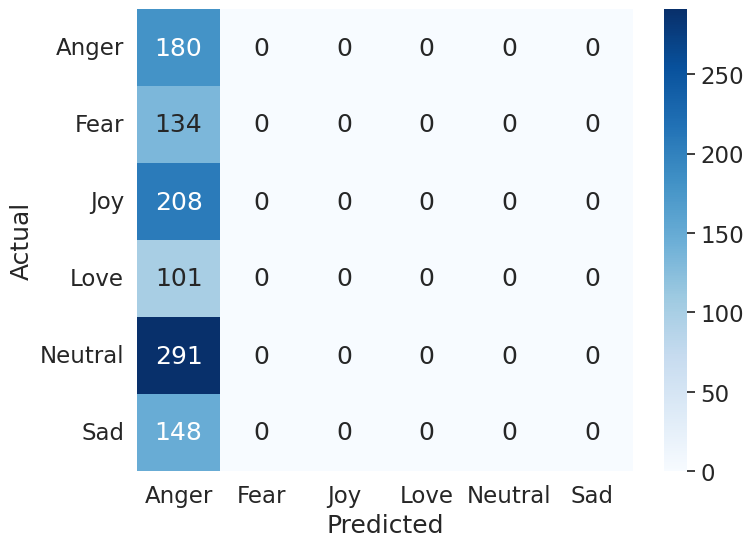

Training finished!


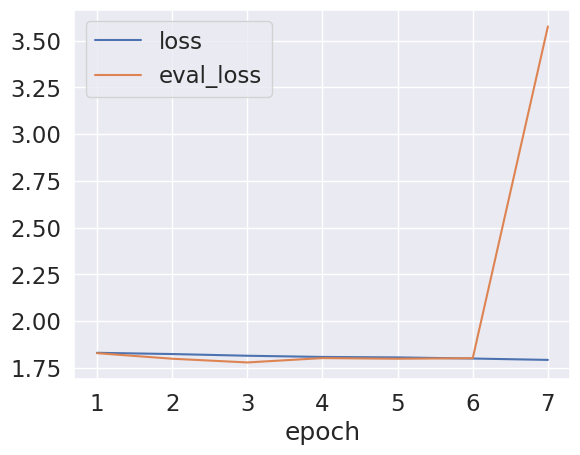

Total time: 13.041577879587809 minutes


In [24]:
#2 FacebookAI/xlm-roberta-large peft

main(
    model_name = 'FacebookAI/xlm-roberta-large',
    output_dir = 'p-emotcls-xlm-r-large',
    best_params = 'best_params/p-xlm-r-large.json'
)

In [28]:
%cd content/

[Errno 2] No such file or directory: 'content/'
/content/fine_tuning


In [31]:
!zip -r fine_tuning.zip /content/fine_tuning/

  adding: content/fine_tuning/ (stored 0%)
  adding: content/fine_tuning/bert_fine_tuning_peft.py (deflated 65%)
  adding: content/fine_tuning/run_hp_tuning_peft.sh (deflated 72%)
  adding: content/fine_tuning/p-emotcls-bert-base/ (stored 0%)
  adding: content/fine_tuning/p-emotcls-bert-base/runs/ (stored 0%)
  adding: content/fine_tuning/p-emotcls-bert-base/runs/Oct01_07-15-36_4412085ff7e2/ (stored 0%)
  adding: content/fine_tuning/p-emotcls-bert-base/runs/Oct01_07-15-36_4412085ff7e2/events.out.tfevents.1790838937.4412085ff7e2.694.6 (deflated 63%)
  adding: content/fine_tuning/p-emotcls-bert-base/runs/Oct01_07-15-36_4412085ff7e2/events.out.tfevents.1790839288.4412085ff7e2.694.7 (deflated 30%)
  adding: content/fine_tuning/p-emotcls-bert-base/training_args.bin (deflated 53%)
  adding: content/fine_tuning/p-emotcls-bert-base/checkpoint-2385/ (stored 0%)
  adding: content/fine_tuning/p-emotcls-bert-base/checkpoint-2385/training_args.bin (deflated 53%)
  adding: content/fine_tuning/p-emot

In [32]:
from google.colab import files
files.download('fine_tuning.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>